In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fedesoriano/cern-electron-collision-data/dielectron.csv


"Exploring Hidden Structures in CERN Collision Data Using Principal Component Analysis and Unsupervised Machine Learning."

In [2]:
dielectron = pd.read_csv('/kaggle/input/datasets/fedesoriano/cern-electron-collision-data/dielectron.csv')
dielectron.head()

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,147115,366639895,58.71410,-7.31132,10.531000,-57.29740,12.82020,-2.20267,2.17766,1,11.2836,-1.032340,-1.88066,-11.0778,2.14537,-2.344030,-2.072810,-1,8.94841
1,147115,366704169,6.61188,-4.15213,-0.579855,-5.11278,4.19242,-1.02842,-3.00284,-1,17.1492,-11.713500,5.04474,11.4647,12.75360,0.808077,2.734920,1,15.89300
2,147115,367112316,25.54190,-11.48090,2.041680,22.72460,11.66100,1.42048,2.96560,1,15.8203,-1.472800,2.25895,-15.5888,2.69667,-2.455080,2.148570,1,38.38770
3,147115,366952149,65.39590,7.51214,11.887100,63.86620,14.06190,2.21838,1.00721,1,25.1273,4.087860,2.59641,24.6563,4.84272,2.330210,0.565865,-1,3.72862
4,147115,366523212,61.45040,2.95284,-14.622700,-59.61210,14.91790,-2.09375,-1.37154,-1,13.8871,-0.277757,-2.42560,-13.6708,2.44145,-2.423700,-1.684810,-1,2.74718


In [3]:
dielectron.columns

Index(['Run', 'Event', 'E1', 'px1 ', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1',
       'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'M'],
      dtype='object')

In [4]:
dielectron.shape

(100000, 19)

The dataset contains 100,000 dielectron collision events described by 19 variables, including the energies, momentum components, transverse momentum, pseudorapidity, azimuthal angle, electric charge of the two electrons, and the invariant mass of the electron pair. Since the objective is to discover hidden structures without predefined labels, the analysis follows an unsupervised machine learning approach.

In [5]:
dielectron.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Run     100000 non-null  int64  
 1   Event   100000 non-null  int64  
 2   E1      100000 non-null  float64
 3   px1     100000 non-null  float64
 4   py1     100000 non-null  float64
 5   pz1     100000 non-null  float64
 6   pt1     100000 non-null  float64
 7   eta1    100000 non-null  float64
 8   phi1    100000 non-null  float64
 9   Q1      100000 non-null  int64  
 10  E2      100000 non-null  float64
 11  px2     100000 non-null  float64
 12  py2     100000 non-null  float64
 13  pz2     100000 non-null  float64
 14  pt2     100000 non-null  float64
 15  eta2    100000 non-null  float64
 16  phi2    100000 non-null  float64
 17  Q2      100000 non-null  int64  
 18  M       99915 non-null   float64
dtypes: float64(15), int64(4)
memory usage: 14.5 MB


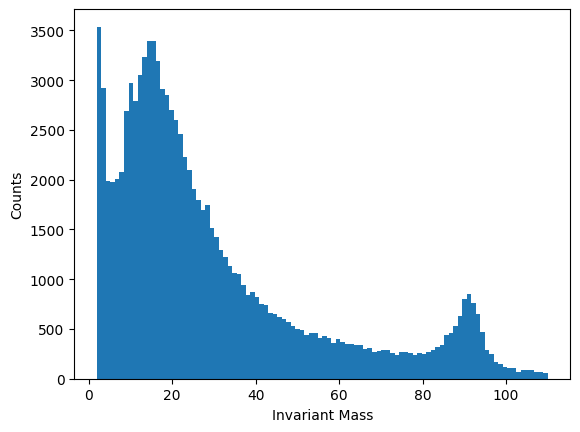

In [6]:
import matplotlib.pyplot as plt

plt.hist(dielectron["M"], bins=100)
plt.xlabel("Invariant Mass")
plt.ylabel("Counts")
plt.show()

The invariant mass distribution is strongly skewed toward lower masses, indicating that low-mass electron pair events occur much more frequently than high-mass events. A noticeable peak appears around 90 GeV, which is consistent with the well-known Z boson resonance, where the decay of the Z boson produces electron-positron pairs. This confirms that the dataset contains physically meaningful collision events rather than randomly generated measurements.

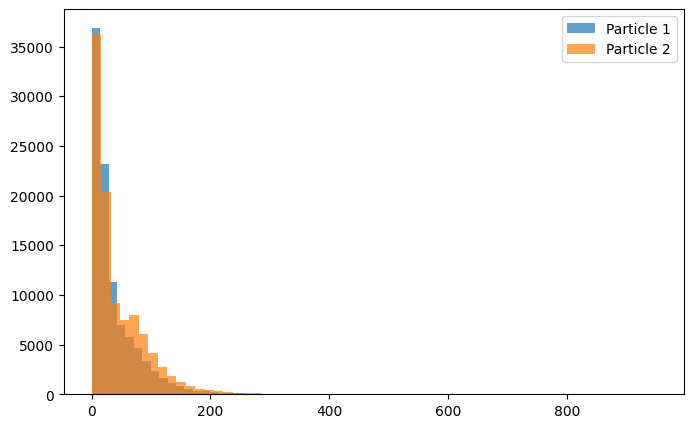

In [7]:
plt.figure(figsize=(8,5))
plt.hist(dielectron["E1"], bins=60, alpha=0.7, label="Particle 1")
plt.hist(dielectron["E2"], bins=60, alpha=0.7, label="Particle 2")
plt.legend()
plt.show()

The energy distributions of both electrons are highly right-skewed. Most collision events contain electrons with relatively low energies, while only a small fraction reach very high energies. The similar distributions of E1 and E2 indicate that the two detected particles exhibit comparable energy characteristics, which is expected for electron pairs produced in high-energy collisions.

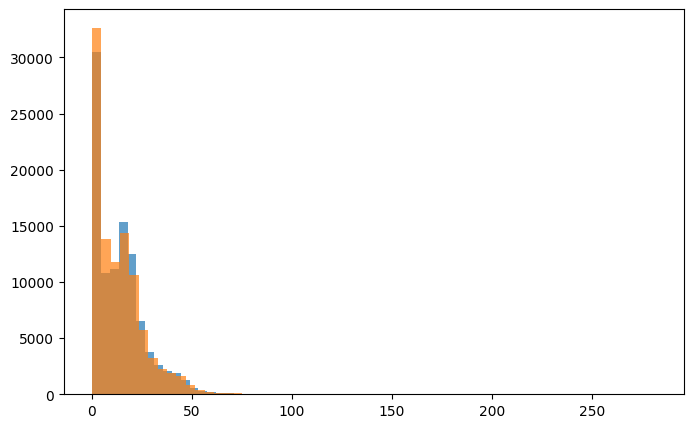

In [8]:
plt.figure(figsize=(8,5))
plt.hist(dielectron["pt1"], bins=60, alpha=0.7)
plt.hist(dielectron["pt2"], bins=60, alpha=0.7)
plt.show()

The transverse momentum (pt1 and pt2) distributions show a similar pattern to the energy distributions. Most electrons possess relatively small transverse momentum, while high transverse momentum events occur much less frequently. This suggests that highly energetic transverse collisions are comparatively rare within the dataset.

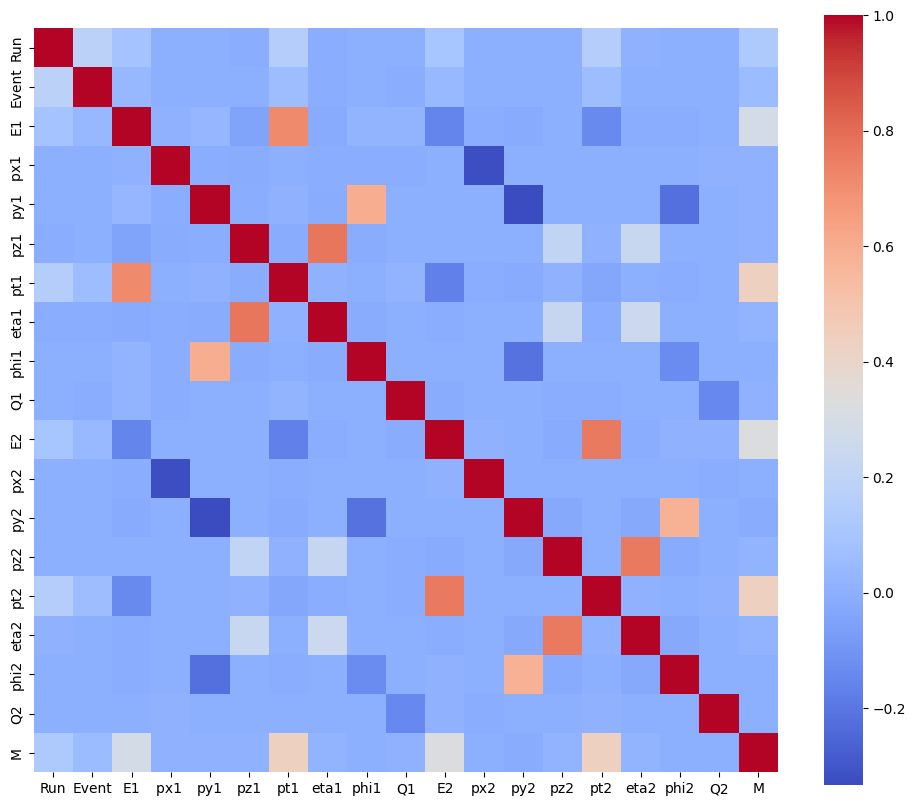

In [9]:
import seaborn as sns

plt.figure(figsize=(12,10))
corr = dielectron.corr()
sns.heatmap(corr,
            cmap="coolwarm",
            square=True)

plt.show()

The correlation matrix shows that most variables exhibit weak to moderate linear correlations. Stronger positive correlations appear between physically related quantities such as energy and transverse momentum. The invariant mass also shows moderate correlations with several kinematic variables because it is derived from the energies and momenta of the two particles. Overall, the absence of extremely strong correlations indicates that the dataset contains information distributed across multiple independent physical variables.

In [10]:
data = dielectron.drop(columns=["Run","Event", "M"])

In [11]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled = scaler.fit_transform(data)

In [12]:
scaled_df = pd.DataFrame(scaled, columns=data.columns)

scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
E1,100000.0,9.578116e-17,1.000005,-0.874868,-0.678811,-0.357130,0.329165,19.753629
px1,100000.0,-1.065814e-17,1.000005,-18.703812,-0.400568,0.000406,0.416166,10.026409
py1,100000.0,-1.477929e-17,1.000005,-9.373369,-0.405230,-0.006177,0.405769,10.934103
pz1,100000.0,3.268497e-18,1.000005,-16.267902,-0.278117,0.023158,0.285266,14.758797
pt1,100000.0,3.205969e-16,1.000005,-1.145606,-0.858929,-0.116588,0.452571,20.273820
eta1,100000.0,3.261391e-17,1.000005,-2.805008,-0.834254,0.001995,0.826536,1.837775
phi1,100000.0,3.183231e-17,1.000005,-1.757767,-0.860572,0.007063,0.856180,1.733656
Q1,100000.0,-4.600764e-17,1.000005,-0.994535,-0.994535,-0.994535,1.005495,1.005495
E2,100000.0,1.116973e-16,1.000005,-0.931114,-0.704739,-0.400812,0.490314,19.344486
px2,100000.0,3.730349e-18,1.000005,-17.804524,-0.364947,-0.002411,0.367441,17.317599


In [13]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(scaled_df)

Principal Component Analysis (PCA) was applied to reduce the dimensionality of the dataset while preserving as much information as possible. Before applying PCA, all variables were standardized so that features measured on different scales contributed equally to the analysis. The invariant mass (M) was excluded because it is a derived quantity calculated from the other kinematic variables. Excluding it prevents the dimensionality reduction process from being dominated by information that is already contained within the remaining features.

In [14]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.1389841  0.1290074  0.12352451 0.09332088 0.08302565 0.08199432
 0.07157305 0.07121662 0.05366228 0.04209629 0.0264343  0.02400907
 0.02020472 0.01467574 0.0142407  0.01203037]


The first principal component explains approximately 13.9% of the total variance, while the second explains about 12.9%. Together, the first two principal components retain only 26.8% of the total information contained in the original dataset. This indicates that the collision events cannot be adequately represented in only two dimensions.

The cumulative explained variance shows that approximately 89% of the total variance is retained using the first 10 principal components, whereas more than 94% is retained using 12 principal components. Therefore, the dataset possesses a relatively complex structure, requiring multiple principal components to preserve most of the underlying information.

In [15]:
cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.1389841  0.2679915  0.39151601 0.48483688 0.56786253 0.64985685
 0.7214299  0.79264653 0.84630881 0.8884051  0.9148394  0.93884847
 0.95905319 0.97372893 0.98796963 1.        ]


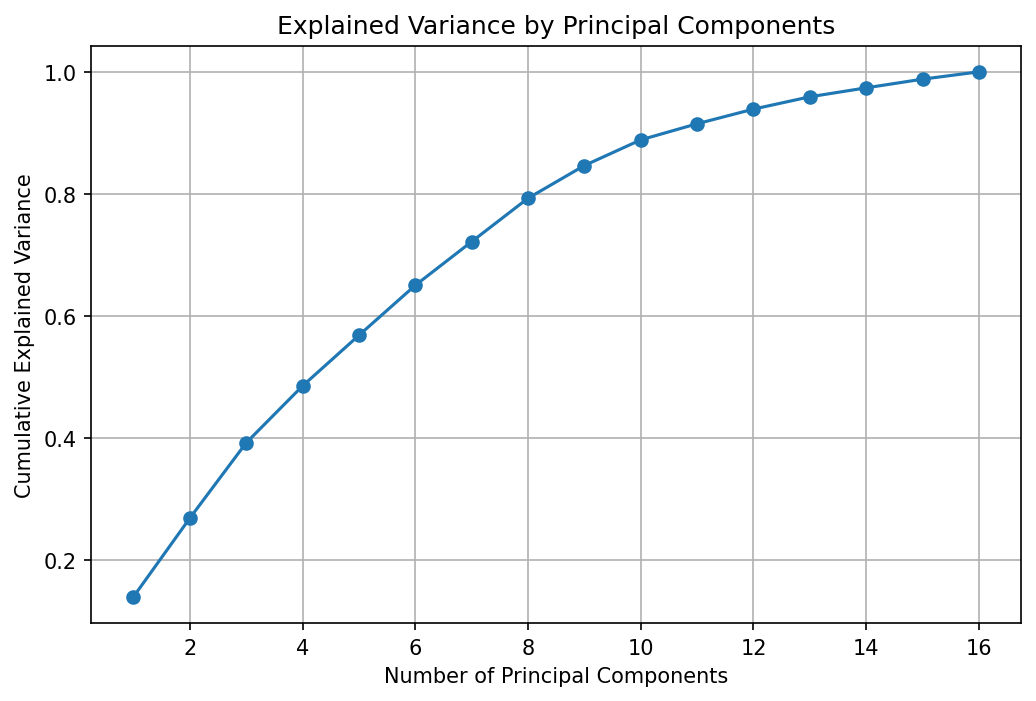

In [16]:
plt.figure(figsize=(8,5), dpi=150)

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Principal Components")

plt.grid(True)

plt.show()

In [17]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=data.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
E1,-0.037808,0.233686,-0.430502,0.496101,-0.031820,-0.037930,0.002399,0.020411,-0.013613,0.015449,-0.001584,0.022493,0.606732,-0.006873,-0.029740,0.373700
px1,-0.014806,-0.005760,-0.012999,0.010984,0.662534,-0.243244,0.011826,-0.028986,-0.027742,0.706669,0.004667,-0.001011,-0.013011,0.001973,-0.000919,-0.003275
py1,0.009553,0.487192,0.215511,-0.022919,-0.024575,-0.046375,0.410590,-0.096202,0.001358,0.002764,0.345940,0.643450,-0.033355,0.003539,0.002575,-0.012079
pz1,0.496259,-0.043375,-0.012033,-0.035448,-0.172480,-0.472776,-0.014934,0.000253,-0.005226,0.008428,-0.004773,0.002240,0.008774,0.055281,-0.702295,-0.021874
pt1,-0.013729,0.214346,-0.410918,0.535609,-0.045881,-0.053209,-0.019036,0.022507,-0.016657,-0.001276,-0.014824,-0.024324,-0.553352,0.013733,0.012252,-0.429772
eta1,0.504305,-0.035307,-0.029513,-0.023456,-0.164353,-0.460613,-0.016862,0.002999,-0.001968,0.007584,-0.002381,0.000421,0.015434,-0.078978,0.703926,0.038527
phi1,0.005462,0.428964,0.194063,-0.027544,-0.028313,-0.043505,0.540329,-0.136066,-0.000974,0.006816,-0.430128,-0.528377,0.009996,-0.005266,0.001077,0.002993
Q1,-0.006805,0.010269,-0.029265,0.015632,-0.025040,-0.000649,-0.165228,-0.685846,0.706949,0.024760,0.006464,-0.000493,0.000615,-0.000310,-0.000855,-0.001540
E2,-0.000305,-0.195676,0.506093,0.441788,-0.016307,-0.026931,-0.008084,-0.014872,-0.004943,0.011368,0.006458,0.002447,0.424621,-0.006581,0.025960,-0.572630
px2,0.005770,-0.000055,0.015215,-0.024998,-0.657090,0.256681,-0.015792,0.040664,-0.010864,0.706444,0.011590,-0.006154,-0.010052,0.006879,0.002680,0.006795


In [18]:
loadings[["PC1", "PC2"]]

,PC1,PC2
E1,-0.037808,0.233686
px1,-0.014806,-0.005760
py1,0.009553,0.487192
pz1,0.496259,-0.043375
pt1,-0.013729,0.214346
eta1,0.504305,-0.035307
phi1,0.005462,0.428964
Q1,-0.006805,0.010269
E2,-0.000305,-0.195676
px2,0.005770,-0.000055


The loading matrix indicates how strongly each original variable contributes to every principal component. Variables with larger absolute loading values have a greater influence on the corresponding principal component. Examining the loading matrix provides a physical interpretation of the new feature space by identifying whether each principal component is primarily influenced by energy, momentum, angular variables, or electric charge.

In [24]:
loadings[['PC1', 'PC2']].sort_values(by='PC1', key=abs, ascending=False)

,PC1,PC2
eta1,0.504305,-0.035307
eta2,0.502976,0.009529
pz1,0.496259,-0.043375
pz2,0.491284,0.014379
py2,-0.040722,-0.477973
E1,-0.037808,0.233686
phi2,-0.035030,-0.420997
px1,-0.014806,-0.005760
pt1,-0.013729,0.214346
pt2,0.011589,-0.174654


In [25]:
loadings[['PC1', 'PC2']].sort_values(by='PC2', key=abs, ascending=False)

,PC1,PC2
py1,0.009553,0.487192
py2,-0.040722,-0.477973
phi1,0.005462,0.428964
phi2,-0.035030,-0.420997
E1,-0.037808,0.233686
pt1,-0.013729,0.214346
E2,-0.000305,-0.195676
pt2,0.011589,-0.174654
pz1,0.496259,-0.043375
eta1,0.504305,-0.035307


In [26]:
pca2 = PCA(n_components=2)

X_pca = pca2.fit_transform(data)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1","PC2"]
)

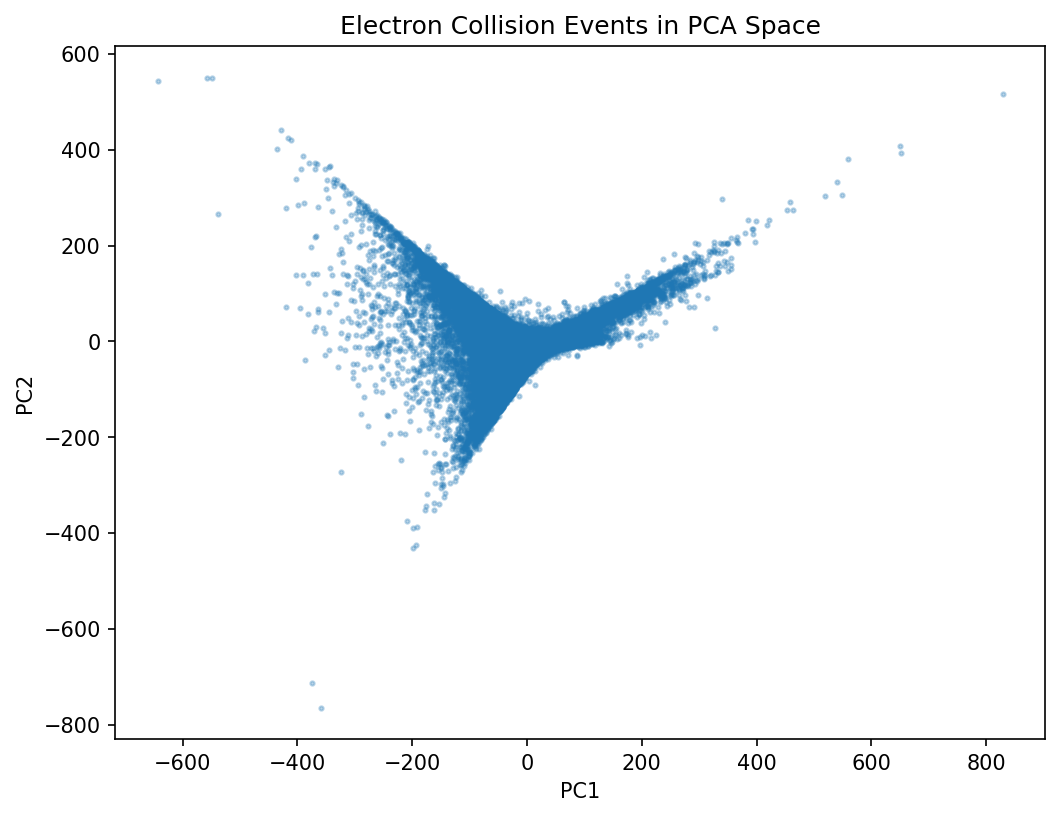

In [27]:
plt.figure(figsize=(8,6), dpi=150)

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    s=4,
    alpha=0.3
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Electron Collision Events in PCA Space")

plt.show()

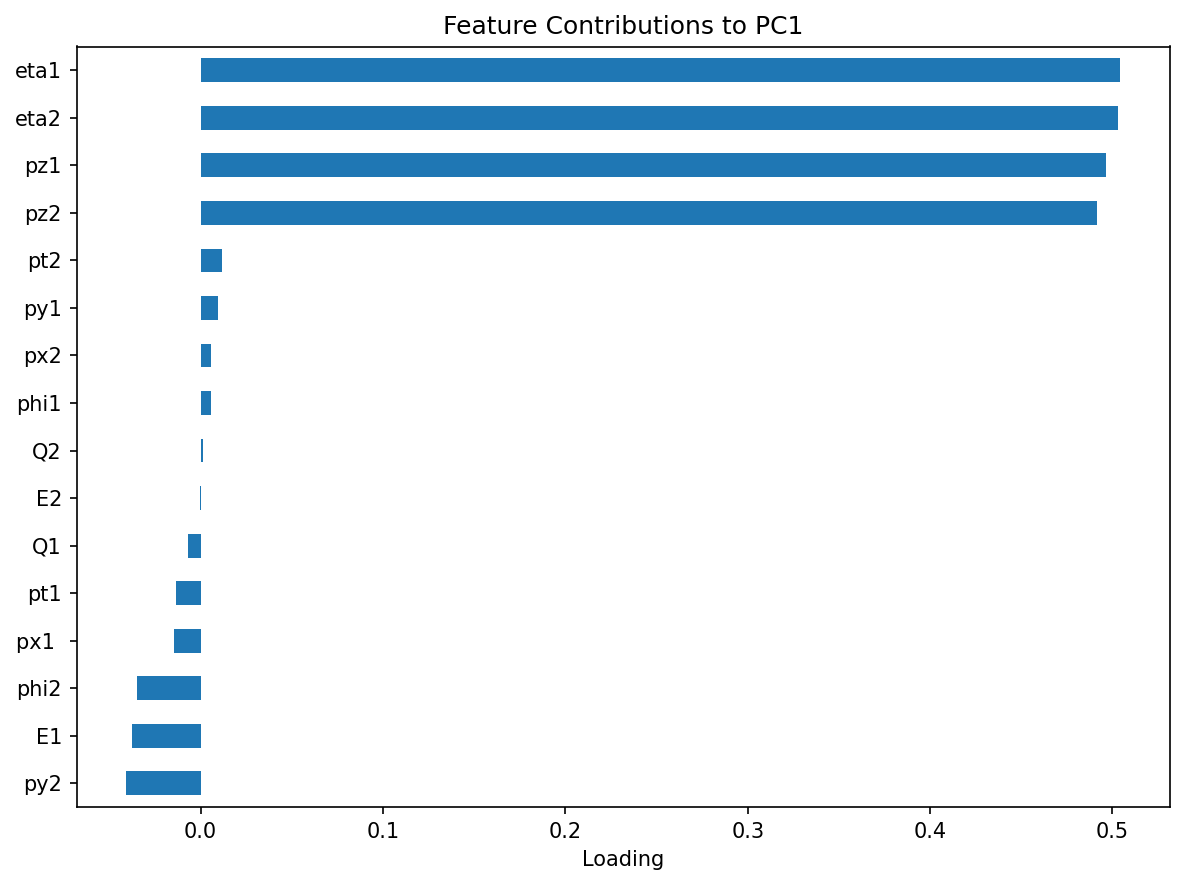

In [28]:
plt.figure(figsize=(8,6), dpi=150)

loadings["PC1"].sort_values().plot(kind="barh")

plt.title("Feature Contributions to PC1")
plt.xlabel("Loading")

plt.tight_layout()
plt.show()

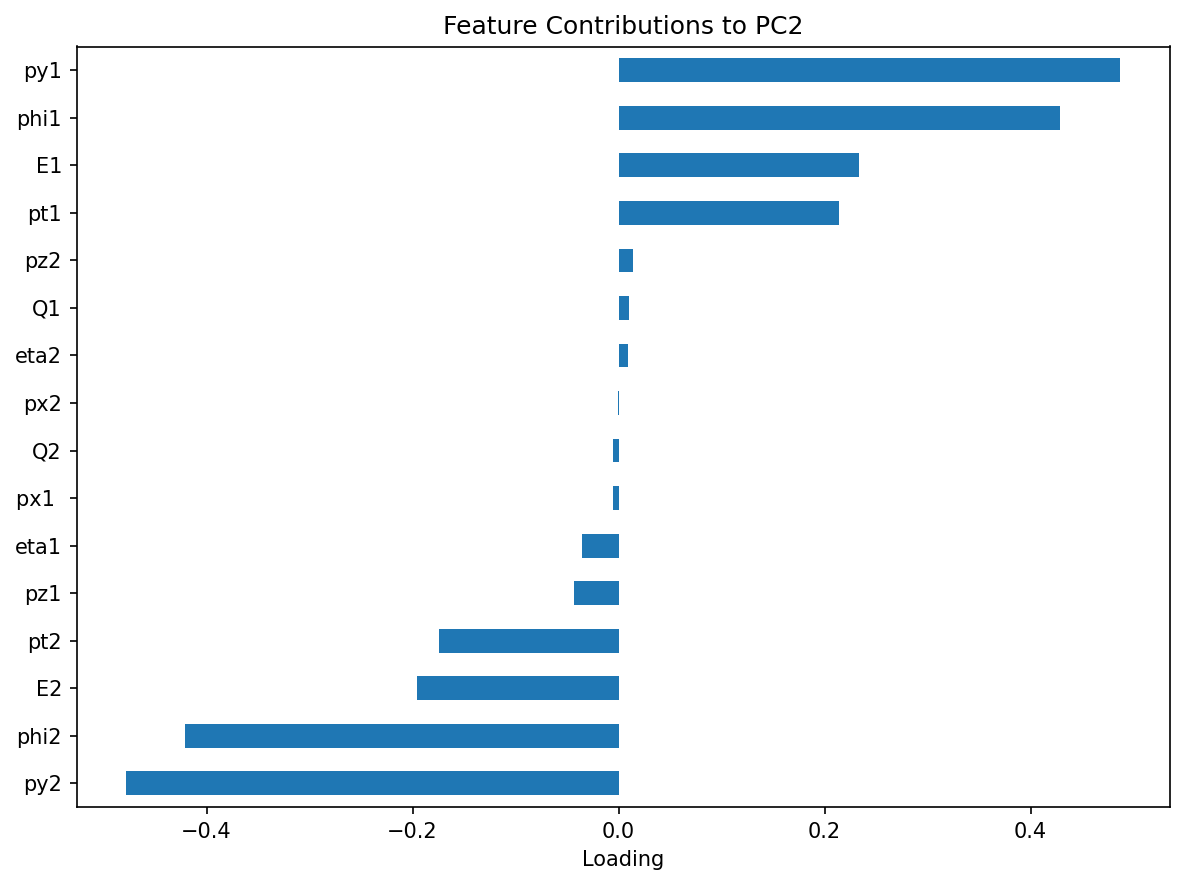

In [29]:
plt.figure(figsize=(8,6), dpi=150)

loadings["PC2"].sort_values().plot(kind="barh")

plt.title("Feature Contributions to PC2")
plt.xlabel("Loading")

plt.tight_layout()
plt.show()

In [34]:
pca10 = PCA(n_components=10)

X10 = pca10.fit_transform(data)

In [35]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X10)

    inertia.append(model.inertia_)

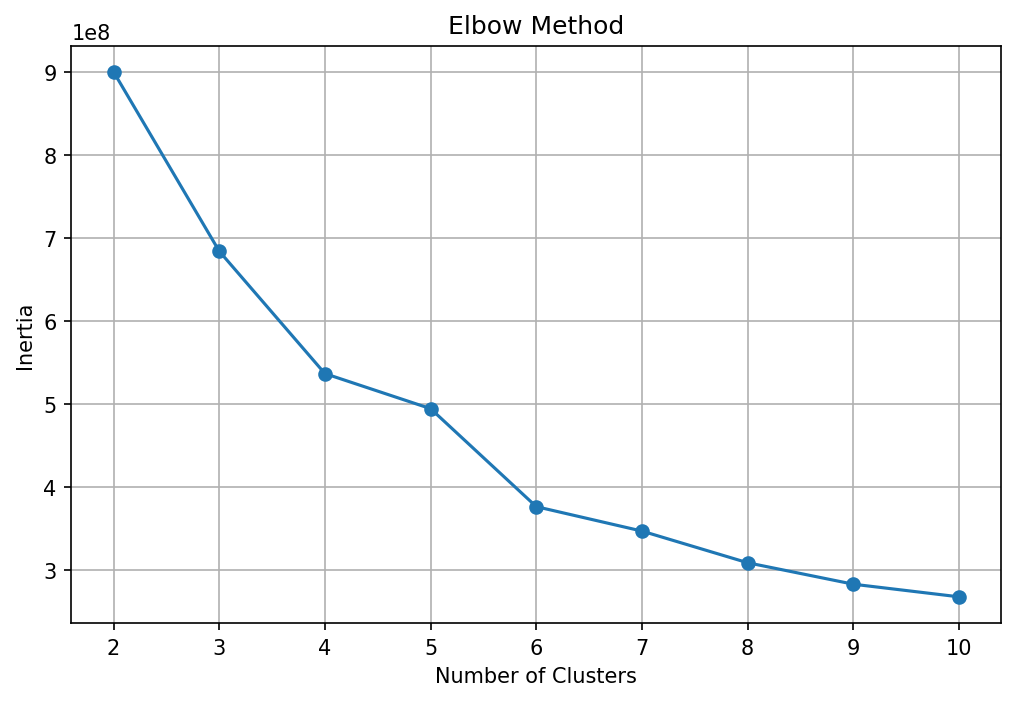

In [36]:
plt.figure(figsize=(8,5),dpi=150)

plt.plot(range(2,11),inertia,marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

The Elbow Method was used to estimate the appropriate number of clusters for K-Means clustering. The inertia decreases rapidly as the number of clusters increases from two to approximately six. Beyond six clusters, the improvement becomes progressively smaller, indicating diminishing returns from adding additional clusters. Consequently, k = 6 was selected as a reasonable balance between model complexity and clustering performance.

In [38]:
kmeans = KMeans(
    n_clusters=6,
    random_state=42
)

labels = kmeans.fit_predict(X10)

K-Means clustering was performed on the reduced PCA feature space using six clusters. Since the clustering was performed without class labels, the algorithm grouped collision events solely according to similarities in their kinematic properties. This approach enables the identification of naturally occurring event populations within the dataset.

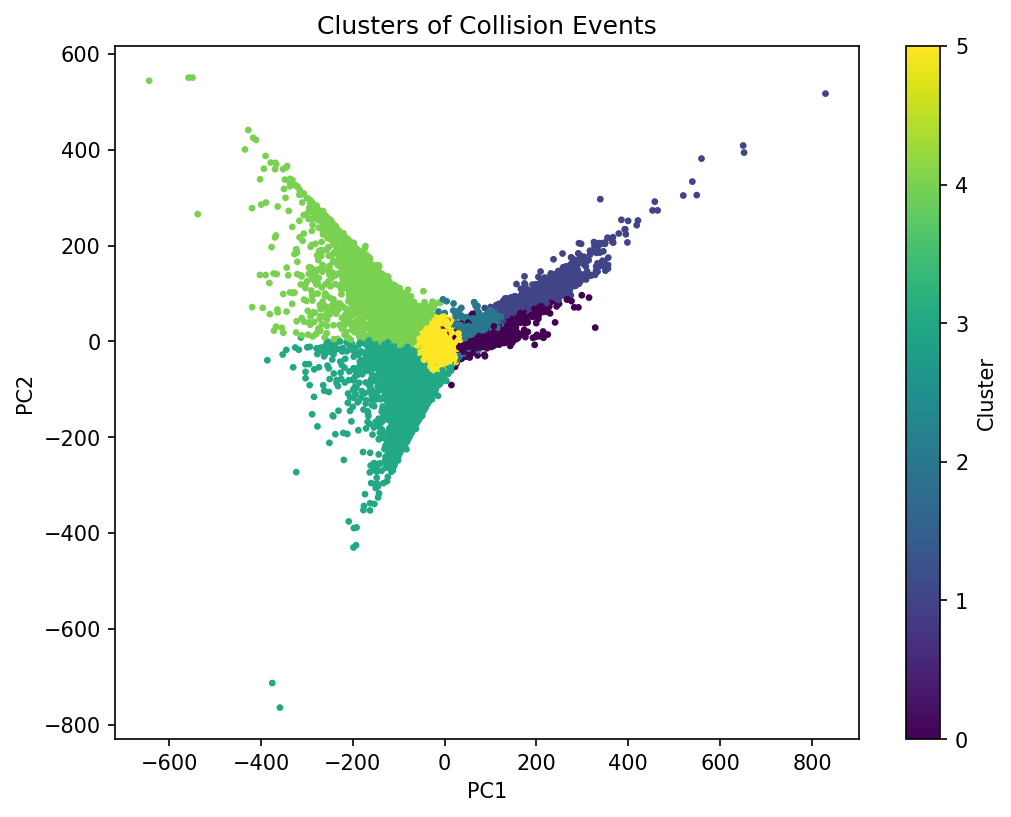

In [39]:
pca_df["Cluster"] = labels

plt.figure(figsize=(8,6),dpi=150)

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    s=5,
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Clusters of Collision Events")

plt.colorbar(label="Cluster")

plt.show()

The invariant mass distributions of the six clusters exhibit similar overall shapes. Each cluster contains a large number of low-mass events together with a visible enhancement near the Z boson mass (~90 GeV). This observation suggests that the clustering algorithm did not primarily separate events according to invariant mass.

This result is expected because invariant mass was intentionally excluded from the PCA before clustering. Instead, the clustering algorithm grouped events according to similarities in the complete set of kinematic variables, including energy, momentum, pseudorapidity, azimuthal angle, and electric charge. Since invariant mass is calculated from these variables, every cluster naturally contains a broad range of invariant mass values.

In [40]:
dielectron["Cluster"] = labels

dielectron.groupby("Cluster")["M"].describe()

,count,mean,std,min,25%,50%,75%,max
Cluster,,,,,,,,
0,9569.0,36.956356,28.992485,2.00708,14.824000,25.42890,58.30800,109.904
1,2527.0,53.126565,31.377271,2.06880,24.526350,46.61830,87.65590,109.924
2,13436.0,35.859079,26.847205,2.00037,15.712425,26.66365,50.33715,109.903
3,10489.0,35.620101,28.884528,2.00408,14.053200,24.30990,55.15260,109.996
4,14571.0,36.508205,27.634711,2.00096,15.944150,26.55970,51.85765,109.999
5,49323.0,22.791221,19.025676,2.00008,10.210450,17.32800,28.95505,109.785


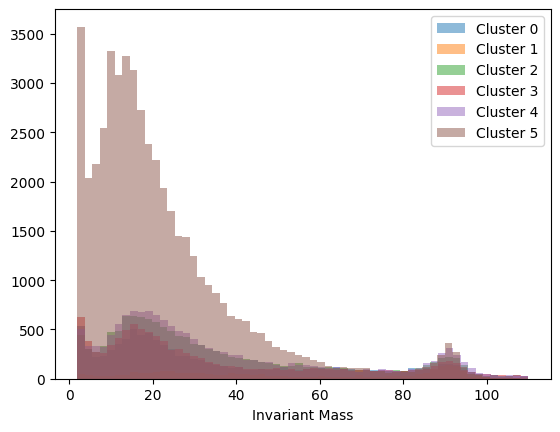

In [41]:
for cluster in sorted(dielectron["Cluster"].unique()):
    plt.hist(
        dielectron.loc[
            dielectron["Cluster"]==cluster,
            "M"
        ],
        bins=60,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.legend()

plt.xlabel("Invariant Mass")

plt.show()

In [42]:
cluster_summary = dielectron.groupby("Cluster")[[
    "E1","E2",
    "pt1","pt2",
    "eta1","eta2",
    "M"
]].mean()

cluster_summary

,E1,E2,pt1,pt2,eta1,eta2,M
Cluster,,,,,,,
0,98.870578,19.810812,25.376239,7.511210,2.052262,0.546570,36.956356
1,36.964070,178.378924,15.034350,38.864599,0.770222,2.230708,53.126565
2,15.400477,80.163499,8.148353,21.122495,0.259837,2.037338,35.859079
3,101.330123,21.842687,25.191159,7.909896,-2.087904,-0.717344,35.620101
4,17.872501,102.922488,8.385444,24.024128,-0.492111,-2.149865,36.508205
5,21.736551,19.309175,13.449428,9.983859,-0.048877,-0.135120,22.791221


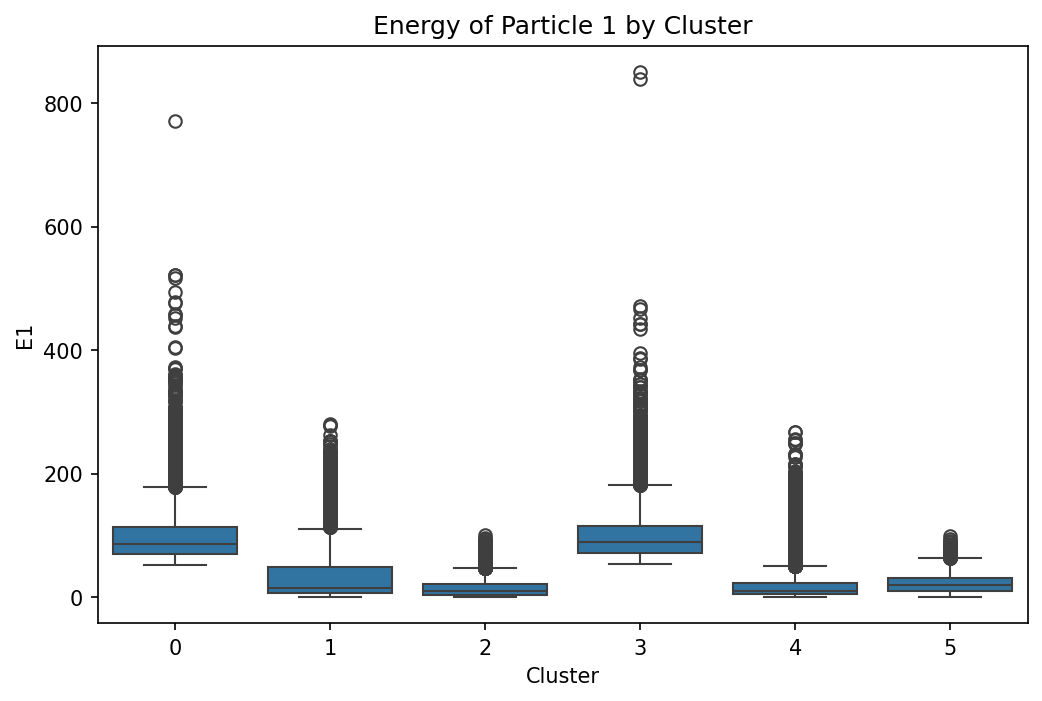

In [43]:
import seaborn as sns

plt.figure(figsize=(8,5), dpi=150)

sns.boxplot(
    data=dielectron,
    x="Cluster",
    y="E1"
)

plt.title("Energy of Particle 1 by Cluster")
plt.show()

In [44]:
dielectron["Cluster"].value_counts().sort_index()

Cluster
0     9569
1     2527
2    13437
3    10489
4    14571
5    49407
Name: count, dtype: int64

This exploratory analysis demonstrates that Principal Component Analysis effectively reduces the dimensionality of the CERN dielectron collision dataset while preserving most of its information. The explained variance analysis shows that approximately ten principal components are required to retain nearly 90% of the original variance, indicating that the collision events possess a relatively complex multidimensional structure.

K-Means clustering identifies six groups of collision events with similar kinematic properties. Although the resulting clusters exhibit comparable invariant mass distributions, this is consistent with the analysis design because invariant mass was excluded during dimensionality reduction. The clustering therefore reflects similarities in the underlying particle kinematics rather than simply separating events by mass.

Overall, the combination of PCA and K-Means provides a useful framework for exploring the intrinsic structure of high-energy collision data and demonstrates how unsupervised machine learning can reveal patterns in multidimensional particle physics datasets without requiring predefined event labels.